<a href="https://colab.research.google.com/github/Poorvi-M/Heart-Disease-Prediction/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Importing Data**

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")
print("Path to dataset files:", path)

import pandas as pd
import os

files = os.listdir(path)
print("Files found:", files)
df = pd.read_csv(path + "/" + files[0])

!pip install ydata-profiling
from ydata_profiling import ProfileReport
import pandas as pd

ProfileReport(df).to_notebook_iframe()

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Path to dataset files: /kaggle/input/heart-disease-dataset
Files found: ['heart.csv']
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.2 MB/s eta 0:00:00


/tmp/ipykernel_13798/267385493.py:15: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install data-profiling via `pip install data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:00<00:00, 42.56it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

**Data Exploration**

In [2]:
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.describe()
df.value_counts
df.isnull().sum()
df.head(10)


Shape: (1025, 14)

Column names:
 ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


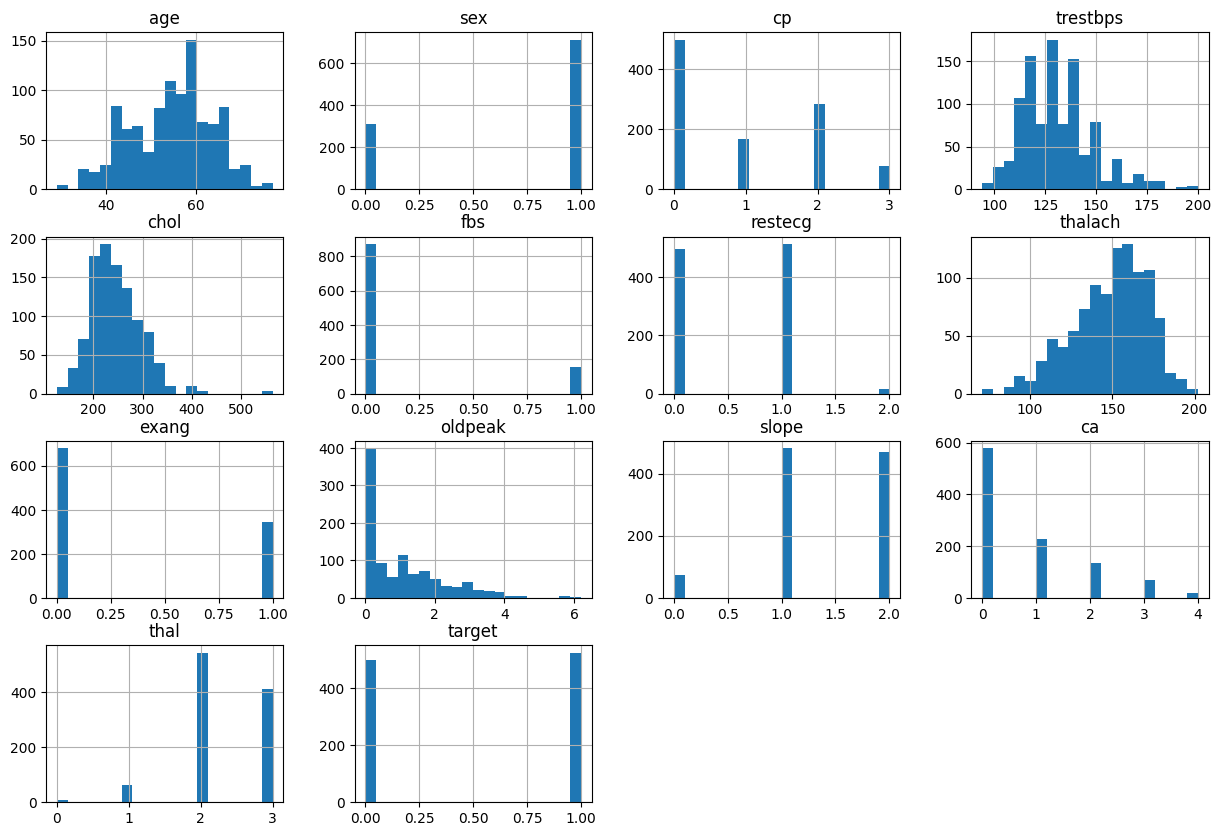

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
df.hist(bins=20, figsize=(15, 10))
plt.show()

In [4]:
df[['chol', 'trestbps', 'age', 'thalach', 'oldpeak']].describe()

,chol,trestbps,age,thalach,oldpeak
count,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000
mean,246.00000,131.611707,54.434146,149.114146,1.071512
std,51.59251,17.516718,9.072290,23.005724,1.175053
min,126.00000,94.000000,29.000000,71.000000,0.000000
25%,211.00000,120.000000,48.000000,132.000000,0.000000
50%,240.00000,130.000000,56.000000,152.000000,0.800000
75%,275.00000,140.000000,61.000000,166.000000,1.800000
max,564.00000,200.000000,77.000000,202.000000,6.200000


**Building a pipeline**

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X=df.drop('target', axis=1)
y=df['target']

pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('standard_scaler', StandardScaler(), ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']),
            ('ohe', OneHotEncoder(handle_unknown="ignore"), ['cp', 'restecg', 'thal'])
        ],
        remainder='passthrough'
    ))
])


**Selecting the best model**

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = pipeline.named_steps['preprocessor']

models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest':       RandomForestClassifier(),
    'XGBoost':             XGBClassifier(),
    'SVM':                 SVC(),
    'Gradient Boosting':   GradientBoostingClassifier()
}


for name, model in models.items():
    model_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='recall')
    print(f"{name}: {scores.mean():.4f} \u00b1 {scores.std():.4f}")

param_grid_lr = {
    'model__C': [0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear', 'saga'],
    'model__max_iter': [1000, 5000] # Increased max_iter for saga solver
}
param_grid_rf = {
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}
param_grid_xgb = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 5]
}
param_grid_svm = {
    'model__C': [0.1, 1, 10, 100],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale', 'auto']
}
param_grid_gbc = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 5]
}

Logistic Regression: 0.8983 ± 0.0178
Random Forest: 0.9859 ± 0.0228
XGBoost: 0.9859 ± 0.0228
SVM: 0.9363 ± 0.0263
Gradient Boosting: 0.9741 ± 0.0282


In [7]:

results = {}

for name, model, param_grid in [
    ('Logistic Regression', LogisticRegression(),     param_grid_lr),
    ('Random Forest',       RandomForestClassifier(), param_grid_rf),
    ('XGBoost',             XGBClassifier(),          param_grid_xgb)
]:
    best_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    grid_search = GridSearchCV(
        estimator=best_pipeline,
        param_grid=param_grid,
        cv=5,
        scoring=['recall','precision'],
        refit='recall',
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    results[name] = {
        'best_score'     : grid_search.best_score_,
        'best_params'    : grid_search.best_params_,
        'best_estimator' : grid_search.best_estimator_
    }

    print(f"\n{name}")
    print(f"  Best Params:    {results[name]['best_params']}")
    print(f"  Best CV Recall: {results[name]['best_score']:.4f}")



Logistic Regression
  Best Params:    {'model__C': 0.1, 'model__max_iter': 1000, 'model__penalty': 'l1', 'model__solver': 'saga'}
  Best CV Recall: 0.9031

Random Forest
  Best Params:    {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
  Best CV Recall: 0.9906

XGBoost
  Best Params:    {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
  Best CV Recall: 0.9859


**Testing the model on test data and getting classification report**

In [8]:
best_model = results['Random Forest']['best_estimator']
y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



**Severity score when heart disease is present**

In [16]:
import numpy as np

#create copy of test set
test_copy= X_test.copy().reset_index(drop=True)
new_df = test_copy[y_pred==1].copy()

#calculating scores, normalisation
ca_score = (new_df['ca'] / 4)*40
oldpeak_score = (new_df['oldpeak'] / 6.2) * 30
exang_score = new_df['exang'] *20
conditions = [
    new_df['thal'] == 0,
    new_df['thal'] == 1,
    new_df['thal'] == 2
]
choices = [0, 10, 7]
thal_score = np.select(conditions, choices)

new_df['ca_score'] = ca_score
new_df['oldpeak_score'] = oldpeak_score
new_df['exang_score'] =exang_score
new_df['thal_score'] = thal_score
new_df['risk_score'] = ca_score + oldpeak_score+ exang_score + thal_score

labels = ['mild', 'moderate', 'high']
new_df['severity'] = pd.cut(new_df['risk_score'], bins=[-1,16,32,47], labels=labels)

new_df['severity'].value_counts()
new_df[['ca', 'oldpeak', 'exang', 'thal', 'risk_score', 'severity']].head(10)


,ca,oldpeak,exang,thal,risk_score,severity
0,0,0.0,0,2,7.000000,mild
1,0,0.0,0,0,0.000000,mild
3,0,1.1,0,2,12.322581,mild
5,1,0.2,1,2,37.967742,high
8,2,0.0,0,2,27.000000,moderate
10,1,0.0,0,2,17.000000,moderate
12,0,0.0,0,2,7.000000,mild
13,1,0.2,0,3,10.967742,mild
17,0,0.0,0,2,7.000000,mild
18,0,0.5,0,3,2.419355,mild


severity
mild         7.94
moderate    24.55
high        39.92
Name: risk_score, dtype: float64


/tmp/ipykernel_13798/3679853149.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(new_df.groupby('severity')['risk_score'].mean().round(2))


,risk_score
count,100.000000
mean,14.476774
std,11.439000
min,0.000000
25%,7.000000
50%,10.870968
75%,19.040323
max,47.000000


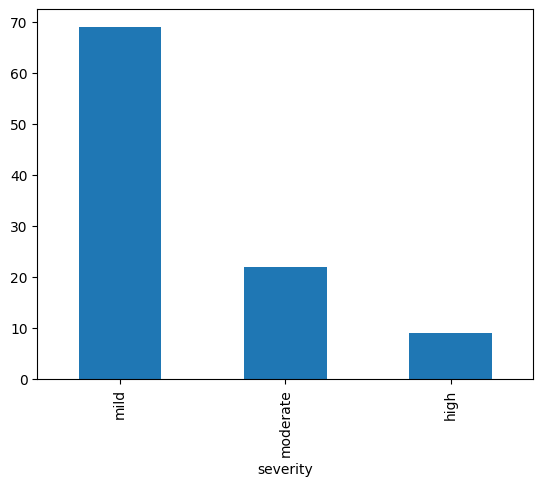

In [17]:
new_df['severity'].value_counts().plot(kind='bar')
print(new_df.groupby('severity')['risk_score'].mean().round(2))
new_df['risk_score'].describe()

**Random Forest Classifier turned out to be the best model with an accuracy of 99%**